# Price Bucket Vector (PBV) Strategy — v4 Logistic Regression

## Concept

Replace the hand-crafted d2 threshold signal with a **logistic regression** that learns the optimal linear combination of bucket-vector features to predict whether executing at tick `t` will beat the TWAP benchmark.

**Target:** `y = 1` if `AskPrice_1[t] < AskPrice_1[minute_start]` (BUY side — lower ask beats TWAP)  
**Features:** bucket d2/d1/cum values, v_mid_cum, Spread, elapsed  
**Warmup:** first `WARMUP_TICKS` ticks of each minute excluded (derivatives not meaningful yet)  
**No hard fallback rule** — LR drives execution; last tick of minute used if model never fires  
**Train/test split:** temporal — first 70% of minutes train, last 30% test

In [1]:
# ============================================================
# CELL 1: Imports & Config
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

STOCK        = "INTC"
SIDE         = "BUY"   # toggle to "SELL" for sell side
WARMUP_TICKS = 30      # suppress first N ticks per minute
THRESHOLD    = 0.5     # P(beat TWAP) threshold to fire execution
TRAIN_FRAC   = 0.70    # fraction of minutes used for training (temporal split)
EPS          = 1e-6

EXEC_PRICE_COL = "AskPrice_1" if SIDE == "BUY" else "BidPrice_1"

FEATURE_COLS = [
    "v_ask_near_d2", "v_ask_far_d2",
    "v_bid_near_d2", "v_bid_far_d2",
    "v_mid_d2",
    "v_ask_near_d1", "v_ask_far_d1",
    "v_mid_cum",
    "v_ask_near_cum", "v_bid_near_cum",
    "Spread",
    "elapsed",
]

print(f"Side: {SIDE} | Exec col: {EXEC_PRICE_COL}")
print(f"Warmup: {WARMUP_TICKS} ticks | Threshold: {THRESHOLD} | Train frac: {TRAIN_FRAC}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Side: BUY | Exec col: AskPrice_1
Warmup: 30 ticks | Threshold: 0.5 | Train frac: 0.7
Features (12): ['v_ask_near_d2', 'v_ask_far_d2', 'v_bid_near_d2', 'v_bid_far_d2', 'v_mid_d2', 'v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed']


In [2]:
# ============================================================
# CELL 2: Data Load + Bucket Computation
# ============================================================
# Vectorised bucket computation — same definitions as v3.
# v_mid      : signed top-of-book imbalance (bid - ask) / (bid + ask)
# v_ask_near : inverse-distance-weighted size at best ask (level 1)
# v_ask_far  : sum of inverse-distance-weighted sizes at ask levels 2-5
# v_bid_near : inverse-distance-weighted size at best bid (level 1)
# v_bid_far  : sum of inverse-distance-weighted sizes at bid levels 2-5

def load_and_compute(stock):
    d = pd.read_csv(f"training_datasets/{stock}_5levels_train.csv")
    d["Time_dt"] = pd.to_datetime(d["Time"], format="%H:%M:%S.%f")
    d["Minute"]  = d["Time_dt"].dt.floor("min")
    d["elapsed"] = (d["Time_dt"] - d["Minute"]).dt.total_seconds()
    d["tick_in_minute"] = d.groupby("Minute").cumcount()

    mid = d["MidPrice"]
    b1, a1 = d["BidSize_1"], d["AskSize_1"]
    d["v_mid"]      = (b1 - a1) / (b1 + a1 + EPS)
    d["v_ask_near"] = d["AskSize_1"] / (d["AskPrice_1"] - mid).clip(lower=EPS)
    d["v_ask_far"]  = sum(d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in range(2, 6))
    d["v_bid_near"] = d["BidSize_1"] / (mid - d["BidPrice_1"]).clip(lower=EPS)
    d["v_bid_far"]  = sum(d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in range(2, 6))

    BUCKET_COLS = ["v_mid", "v_ask_near", "v_ask_far", "v_bid_near", "v_bid_far"]
    grp = d.groupby("Minute")
    for col in BUCKET_COLS:
        d[f"{col}_cum"] = grp[col].cumsum()
        d[f"{col}_d1"]  = grp[f"{col}_cum"].diff()
        d[f"{col}_d2"]  = grp[f"{col}_d1"].diff()

    # Label: 1 if this tick's exec price beats the minute-open TWAP price
    twap_price = grp[EXEC_PRICE_COL].transform("first")
    if SIDE == "BUY":
        d["label"] = (d[EXEC_PRICE_COL] < twap_price).astype(int)
    else:
        d["label"] = (d[EXEC_PRICE_COL] > twap_price).astype(int)

    d["stock"] = stock
    return d


train_raw = load_and_compute(STOCK)

print(f"Shape: {train_raw.shape}")
print(f"Minutes: {train_raw['Minute'].nunique()}")
print(f"Label distribution: {train_raw['label'].value_counts().to_dict()}")
print(f"% positive labels (any tick beats TWAP): {100*train_raw['label'].mean():.1f}%")
train_raw[["label", "elapsed", "tick_in_minute"] + FEATURE_COLS[:4]].describe().round(4)

Shape: (430718, 59)
Minutes: 270
Label distribution: {0: 262418, 1: 168300}
% positive labels (any tick beats TWAP): 39.1%


,label,elapsed,tick_in_minute,v_ask_near_d2,v_ask_far_d2,v_bid_near_d2,v_bid_far_d2
count,430718.0000,430718.0000,430718.0000,4.301780e+05,4.301780e+05,4.301780e+05,4.301780e+05
mean,0.3907,28.9862,1273.7610,6.464800e+00,4.657800e+00,2.956900e+00,5.990600e+00
std,0.4879,17.6123,1514.2792,1.242922e+05,4.072718e+04,1.509055e+05,4.649842e+04
min,0.0000,0.0000,0.0000,-1.434040e+07,-4.780133e+06,-1.301780e+07,-4.552843e+06
25%,0.0000,13.9940,404.0000,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00
50%,0.0000,28.3765,866.0000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.0000,44.4040,1585.0000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.0000,59.9990,12824.0000,1.434040e+07,6.304246e+06,1.301780e+07,4.785652e+06


In [3]:
# ============================================================
# CELL 3: Build Feature Matrix
# ============================================================
# Keep only post-warmup ticks; drop rows with NaN features.

df = train_raw[train_raw["tick_in_minute"] >= WARMUP_TICKS].copy()
df = df.dropna(subset=FEATURE_COLS)

print(f"Post-warmup rows: {len(df)} ({100*len(df)/len(train_raw):.1f}% of all ticks)")
print(f"Label rate post-warmup: {100*df['label'].mean():.1f}%")

# Temporal train/test split — split on minutes, not rows, to avoid leakage
minutes_sorted = sorted(df["Minute"].unique())
n_train = int(len(minutes_sorted) * TRAIN_FRAC)
train_minutes = set(minutes_sorted[:n_train])
test_minutes  = set(minutes_sorted[n_train:])

df_train = df[df["Minute"].isin(train_minutes)]
df_test  = df[df["Minute"].isin(test_minutes)]

print(f"Train minutes: {len(train_minutes)} | rows: {len(df_train)} | label rate: {100*df_train['label'].mean():.1f}%")
print(f"Test  minutes: {len(test_minutes)}  | rows: {len(df_test)}  | label rate: {100*df_test['label'].mean():.1f}%")

Post-warmup rows: 422618 (98.1% of all ticks)
Label rate post-warmup: 39.8%
Train minutes: 189 | rows: 325126 | label rate: 42.0%
Test  minutes: 81  | rows: 97492  | label rate: 32.4%


In [4]:
# ============================================================
# CELL 4: Fit Logistic Regression
# ============================================================
# StandardScaler normalises features — needed because bucket values
# are on very different scales (d2 in millions, elapsed in seconds).
# class_weight='balanced' corrects for label imbalance.

X_train = df_train[FEATURE_COLS].values
y_train = df_train["label"].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test["label"].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(
    C=1.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)
model.fit(X_train_sc, y_train)

train_auc = roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1])
test_auc  = roc_auc_score(y_test,  model.predict_proba(X_test_sc)[:, 1])

print(f"Train AUC: {train_auc:.4f}")
print(f"Test  AUC: {test_auc:.4f}")
print()
print(classification_report(y_test, model.predict(X_test_sc), target_names=["no beat", "beats TWAP"]))

Train AUC: 0.8261
Test  AUC: 0.7956

              precision    recall  f1-score   support

     no beat       0.83      0.81      0.82     65916
  beats TWAP       0.63      0.65      0.64     31576

    accuracy                           0.76     97492
   macro avg       0.73      0.73      0.73     97492
weighted avg       0.76      0.76      0.76     97492



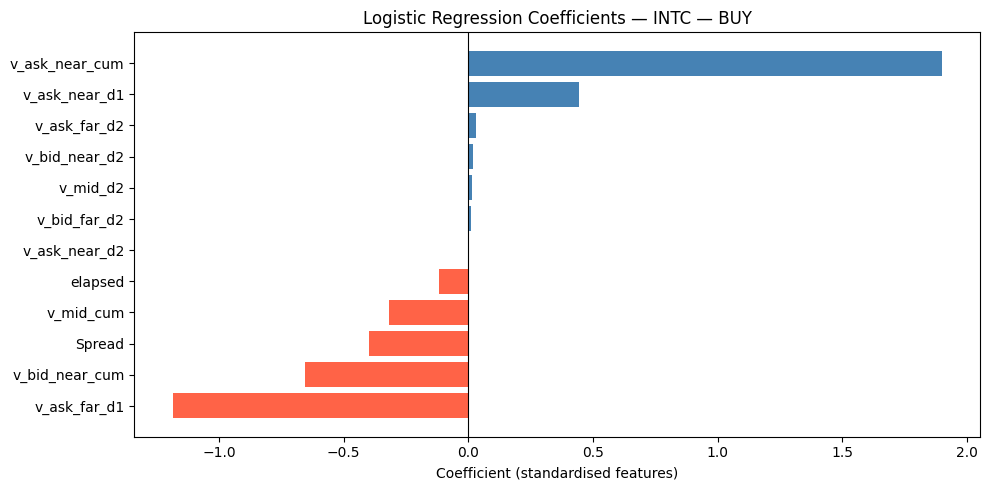

       feature      coef  abs_coef
  v_ask_far_d1 -1.185518  1.185518
v_bid_near_cum -0.656373  0.656373
        Spread -0.398742  0.398742
     v_mid_cum -0.319161  0.319161
       elapsed -0.118878  0.118878
 v_ask_near_d2 -0.002628  0.002628
  v_bid_far_d2  0.012149  0.012149
      v_mid_d2  0.014788  0.014788
 v_bid_near_d2  0.018008  0.018008
  v_ask_far_d2  0.029201  0.029201
 v_ask_near_d1  0.443240  0.443240
v_ask_near_cum  1.898324  1.898324


In [5]:
# ============================================================
# CELL 5: Feature Coefficients
# ============================================================

coef_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coef":    model.coef_[0],
    "abs_coef": np.abs(model.coef_[0]),
}).sort_values("coef")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if c > 0 else "tomato" for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"], color=colors, edgecolor="none")
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"Logistic Regression Coefficients — {STOCK} — {SIDE}")
ax.set_xlabel("Coefficient (standardised features)")
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

In [6]:
# ============================================================
# CELL 6: Simulate Execution on Test Minutes
# ============================================================
# For each test minute: fire at the first post-warmup tick where
# P(beats TWAP) >= THRESHOLD. If model never fires, execute at
# the last tick of the minute.

df_test_scored = df_test.copy()
df_test_scored["prob"] = model.predict_proba(
    scaler.transform(df_test_scored[FEATURE_COLS].values)
)[:, 1]

sim_results = []

for minute, grp in df_test_scored.groupby("Minute"):
    grp = grp.sort_values("elapsed")
    twap_price = train_raw.loc[train_raw["Minute"] == minute, EXEC_PRICE_COL].iloc[0]

    fired = grp[grp["prob"] >= THRESHOLD]
    if not fired.empty:
        exec_row   = fired.iloc[0]
        model_fire = True
    else:
        exec_row   = grp.iloc[-1]   # last tick of minute — no hard fallback rule
        model_fire = False

    pbv_price   = exec_row[EXEC_PRICE_COL]
    exec_second = exec_row["elapsed"]
    improvement = (twap_price - pbv_price) if SIDE == "BUY" else (pbv_price - twap_price)

    sim_results.append({
        "Minute":      minute,
        "twap_price":  twap_price,
        "pbv_price":   pbv_price,
        "improvement": improvement,
        "exec_second": exec_second,
        "model_fire":  model_fire,
    })

sim_df = pd.DataFrame(sim_results)
_mf  = sim_df[sim_df["model_fire"]]
_nmf = sim_df[~sim_df["model_fire"]]

print("=" * 58)
print(f"  PBV v4 Logistic — {STOCK} — {SIDE} — TEST SET")
print("=" * 58)
print(f"  Test minutes       : {len(sim_df)}")
print(f"  Model fired        : {sim_df['model_fire'].sum()} ({100*sim_df['model_fire'].mean():.1f}%)")
print(f"  Last-tick fallback : {(~sim_df['model_fire']).sum()} ({100*(~sim_df['model_fire']).mean():.1f}%)")
print(f"  Mean improvement   : ${sim_df['improvement'].mean():.5f}")
print(f"  Median improvement : ${sim_df['improvement'].median():.5f}")
print(f"  % beating TWAP     : {100*(sim_df['improvement'] > 0).mean():.1f}%")
print(f"  % model-fire beat  : {100*(_mf['improvement'] > 0).mean():.1f}%  (n={len(_mf)})")
print(f"  % last-tick beat   : {100*(_nmf['improvement'] > 0).mean():.1f}%  (n={len(_nmf)})")
print(f"  Mean exec second   : {sim_df['exec_second'].mean():.1f}s")
print()
sim_df.describe()

  PBV v4 Logistic — INTC — BUY — TEST SET
  Test minutes       : 81
  Model fired        : 50 (61.7%)
  Last-tick fallback : 31 (38.3%)
  Mean improvement   : $-0.00012
  Median improvement : $0.00000
  % beating TWAP     : 28.4%
  % model-fire beat  : 44.0%  (n=50)
  % last-tick beat   : 3.2%  (n=31)
  Mean exec second   : 38.5s



,Minute,twap_price,pbv_price,improvement,exec_second
count,81,81.000000,81.000000,81.000000,81.000000
mean,1900-01-01 13:19:00,26.908395,26.908519,-0.000123,38.483778
min,1900-01-01 12:39:00,26.800000,26.790000,-0.020000,1.359000
25%,1900-01-01 12:59:00,26.850000,26.850000,0.000000,16.018000
50%,1900-01-01 13:19:00,26.930000,26.930000,0.000000,49.962000
75%,1900-01-01 13:39:00,26.950000,26.950000,0.010000,59.552000
max,1900-01-01 13:59:00,26.990000,26.980000,0.020000,59.998000
std,NaN,0.058126,0.058033,0.008731,22.097686


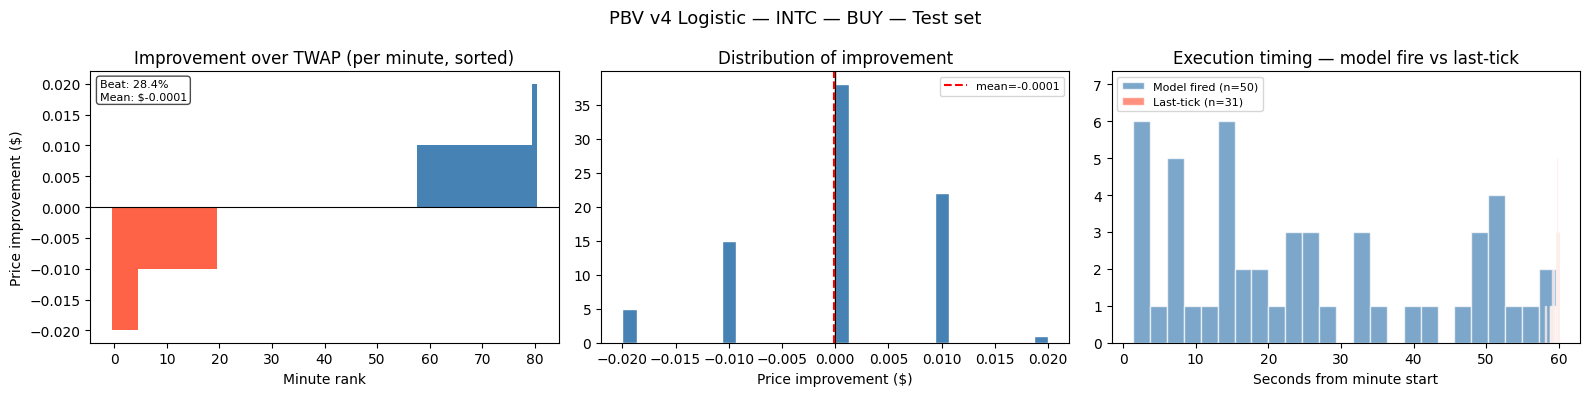

In [7]:
# ============================================================
# CELL 7: Results Visualisation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

s = sim_df["improvement"].sort_values()
axes[0].bar(
    range(len(s)), s.values,
    color=["steelblue" if v >= 0 else "tomato" for v in s.values],
    width=1.0, edgecolor="none"
)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Improvement over TWAP (per minute, sorted)")
axes[0].set_xlabel("Minute rank")
axes[0].set_ylabel("Price improvement ($)")
axes[0].text(0.02, 0.97,
    f"Beat: {100*(sim_df['improvement']>0).mean():.1f}%\nMean: ${sim_df['improvement'].mean():.4f}",
    transform=axes[0].transAxes, va="top", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

axes[1].hist(sim_df["improvement"], bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].axvline(sim_df["improvement"].mean(), color="red", lw=1.5, ls="--",
                label=f"mean={sim_df['improvement'].mean():.4f}")
axes[1].set_title("Distribution of improvement")
axes[1].set_xlabel("Price improvement ($)")
axes[1].legend(fontsize=8)

axes[2].hist(sim_df[sim_df["model_fire"]]["exec_second"],   bins=25, alpha=0.7,
             color="steelblue",  label=f"Model fired (n={sim_df['model_fire'].sum()})",  edgecolor="white")
axes[2].hist(sim_df[~sim_df["model_fire"]]["exec_second"],  bins=25, alpha=0.7,
             color="tomato",     label=f"Last-tick (n={(~sim_df['model_fire']).sum()})", edgecolor="white")
axes[2].set_title("Execution timing — model fire vs last-tick")
axes[2].set_xlabel("Seconds from minute start")
axes[2].legend(fontsize=8)

plt.suptitle(f"PBV v4 Logistic — {STOCK} — {SIDE} — Test set", fontsize=13)
plt.tight_layout()
plt.show()

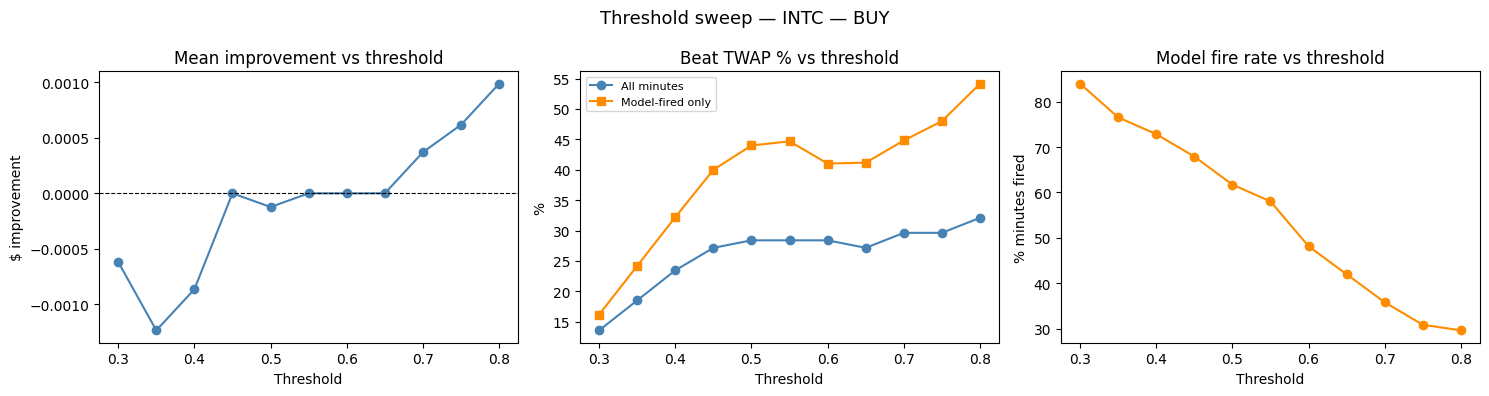

 threshold  fire_pct  beat_pct  mf_beat  mean_imp  exec_s
      0.30    83.951    13.580   16.176    -0.001  21.681
      0.35    76.543    18.519   24.194    -0.001  26.196
      0.40    72.840    23.457   32.203    -0.001  30.170
      0.45    67.901    27.160   40.000     0.000  33.941
      0.50    61.728    28.395   44.000    -0.000  38.484
      0.55    58.025    28.395   44.681    -0.000  40.747
      0.60    48.148    28.395   41.026     0.000  44.950
      0.65    41.975    27.160   41.176    -0.000  46.153
      0.70    35.802    29.630   44.828     0.000  48.246
      0.75    30.864    29.630   48.000     0.001  50.120
      0.80    29.630    32.099   54.167     0.001  51.465


In [8]:
# ============================================================
# CELL 8: Threshold Sensitivity
# ============================================================
# Sweep THRESHOLD to see the precision/coverage tradeoff.

thresholds = np.arange(0.30, 0.85, 0.05)
sweep_rows = []

for thr in thresholds:
    rows = []
    for minute, grp in df_test_scored.groupby("Minute"):
        grp = grp.sort_values("elapsed")
        twap_price = train_raw.loc[train_raw["Minute"] == minute, EXEC_PRICE_COL].iloc[0]
        fired = grp[grp["prob"] >= thr]
        exec_row   = fired.iloc[0] if not fired.empty else grp.iloc[-1]
        model_fire = not fired.empty
        pbv_price  = exec_row[EXEC_PRICE_COL]
        improvement = (twap_price - pbv_price) if SIDE == "BUY" else (pbv_price - twap_price)
        rows.append({"improvement": improvement, "model_fire": model_fire, "exec_s": exec_row["elapsed"]})
    r = pd.DataFrame(rows)
    mf = r[r["model_fire"]]
    sweep_rows.append({
        "threshold": thr,
        "fire_pct":  100 * r["model_fire"].mean(),
        "beat_pct":  100 * (r["improvement"] > 0).mean(),
        "mf_beat":   100 * (mf["improvement"] > 0).mean() if len(mf) else np.nan,
        "mean_imp":  r["improvement"].mean(),
        "exec_s":    r["exec_s"].mean(),
    })

sweep_df = pd.DataFrame(sweep_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sweep_df["threshold"], sweep_df["mean_imp"], marker="o", color="steelblue")
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set(title="Mean improvement vs threshold", xlabel="Threshold", ylabel="$ improvement")

axes[1].plot(sweep_df["threshold"], sweep_df["beat_pct"],  marker="o", color="steelblue",  label="All minutes")
axes[1].plot(sweep_df["threshold"], sweep_df["mf_beat"],   marker="s", color="darkorange", label="Model-fired only")
axes[1].set(title="Beat TWAP % vs threshold", xlabel="Threshold", ylabel="%")
axes[1].legend(fontsize=8)

axes[2].plot(sweep_df["threshold"], sweep_df["fire_pct"], marker="o", color="darkorange")
axes[2].set(title="Model fire rate vs threshold", xlabel="Threshold", ylabel="% minutes fired")

plt.suptitle(f"Threshold sweep — {STOCK} — {SIDE}", fontsize=13)
plt.tight_layout()
plt.show()

print(sweep_df.round(3).to_string(index=False))

Running cross-stock LR pipeline...
Done.

  Cross-stock: LR v4 vs v3 base signal — BUY side
       Test mins    AUC LR mean $ LR beat % LR fire % LR exec s v3 mean $ v3 beat % v3 exec s
Stock                                                                                        
AMZN          81  0.597   0.01444      49.4     100.0       8.7   0.01370      45.7      17.7
GOOG          81  0.601   0.03963      61.7      96.3      14.7   0.00667      53.1      25.7
INTC          81  0.796  -0.00012      28.4      61.7      38.5   0.00235      19.8      23.2
MSFT          81  0.898   0.00012      44.4      46.9      44.8   0.00309      19.8      24.7


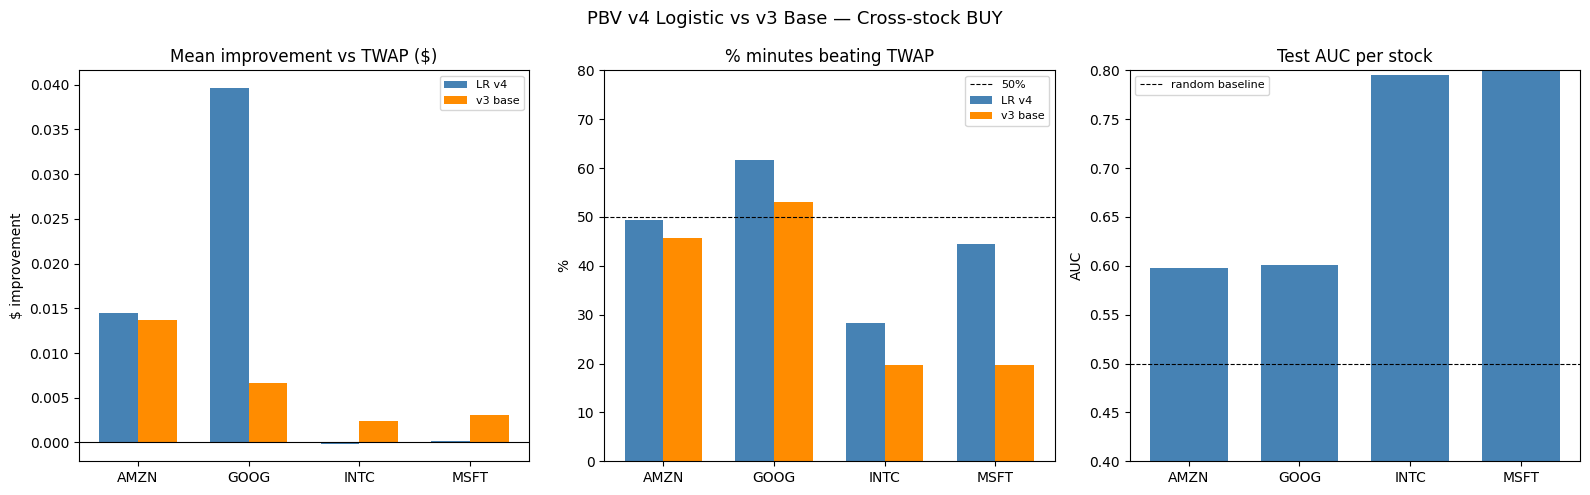

In [9]:
# ============================================================
# CELL 9: Cross-Stock Evaluation
# ============================================================
# Train on each stock's own data (temporal split); compare LR vs
# v3 base signal (warmup=30, no fallback rule) on the same test set.

STOCKS_ALL = ["AMZN", "GOOG", "INTC", "MSFT"]

def run_stock_lr(stock):
    d = load_and_compute(stock)
    df = d[d["tick_in_minute"] >= WARMUP_TICKS].dropna(subset=FEATURE_COLS)

    minutes_sorted = sorted(df["Minute"].unique())
    n_train = int(len(minutes_sorted) * TRAIN_FRAC)
    train_mins = set(minutes_sorted[:n_train])
    test_mins  = set(minutes_sorted[n_train:])

    df_tr = df[df["Minute"].isin(train_mins)]
    df_te = df[df["Minute"].isin(test_mins)]

    sc = StandardScaler()
    Xtr = sc.fit_transform(df_tr[FEATURE_COLS].values)
    Xte = sc.transform(df_te[FEATURE_COLS].values)

    m = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=42)
    m.fit(Xtr, df_tr["label"].values)

    df_te = df_te.copy()
    df_te["prob"] = m.predict_proba(Xte)[:, 1]

    # LR simulation
    lr_rows, v3_rows = [], []
    for minute, grp in df_te.groupby("Minute"):
        grp = grp.sort_values("elapsed")
        twap_price = d.loc[d["Minute"] == minute, EXEC_PRICE_COL].iloc[0]

        # LR: first tick where P >= THRESHOLD, else last tick
        fired_lr = grp[grp["prob"] >= THRESHOLD]
        exec_lr  = fired_lr.iloc[0] if not fired_lr.empty else grp.iloc[-1]
        imp_lr   = (twap_price - exec_lr[EXEC_PRICE_COL]) if SIDE == "BUY" else (exec_lr[EXEC_PRICE_COL] - twap_price)
        lr_rows.append({"improvement": imp_lr, "exec_s": exec_lr["elapsed"], "model_fire": not fired_lr.empty})

        # v3 base signal: warmup=30, no fallback
        warmup_ok = grp["tick_in_minute"] >= WARMUP_TICKS
        if SIDE == "BUY":
            v3_sig = warmup_ok & (grp["v_ask_near_d2"] < 0) & (grp["v_mid_cum"] > 0)
        else:
            v3_sig = warmup_ok & (grp["v_bid_near_d2"] < 0) & (grp["v_mid_cum"] < 0)
        fired_v3 = grp[v3_sig.fillna(False)]
        exec_v3  = fired_v3.iloc[0] if not fired_v3.empty else grp.iloc[-1]
        imp_v3   = (twap_price - exec_v3[EXEC_PRICE_COL]) if SIDE == "BUY" else (exec_v3[EXEC_PRICE_COL] - twap_price)
        v3_rows.append({"improvement": imp_v3, "exec_s": exec_v3["elapsed"]})

    lr_df = pd.DataFrame(lr_rows)
    v3_df = pd.DataFrame(v3_rows)

    return {
        "stock":      stock,
        "test_mins":  len(test_mins),
        "lr_mean":    lr_df["improvement"].mean(),
        "lr_beat":    (lr_df["improvement"] > 0).mean() * 100,
        "lr_fire":    lr_df["model_fire"].mean() * 100,
        "lr_exec_s":  lr_df["exec_s"].mean(),
        "v3_mean":    v3_df["improvement"].mean(),
        "v3_beat":    (v3_df["improvement"] > 0).mean() * 100,
        "v3_exec_s":  v3_df["exec_s"].mean(),
        "test_auc":   roc_auc_score(df_te["label"].values, df_te["prob"].values),
    }

print("Running cross-stock LR pipeline...")
xs_res = {s: run_stock_lr(s) for s in STOCKS_ALL}
print("Done.")

rows = []
for s, r in xs_res.items():
    rows.append({
        "Stock":        s,
        "Test mins":    r["test_mins"],
        "AUC":          f"{r['test_auc']:.3f}",
        "LR mean $":    f"{r['lr_mean']:.5f}",
        "LR beat %":    f"{r['lr_beat']:.1f}",
        "LR fire %":    f"{r['lr_fire']:.1f}",
        "LR exec s":    f"{r['lr_exec_s']:.1f}",
        "v3 mean $":    f"{r['v3_mean']:.5f}",
        "v3 beat %":    f"{r['v3_beat']:.1f}",
        "v3 exec s":    f"{r['v3_exec_s']:.1f}",
    })

summary = pd.DataFrame(rows).set_index("Stock")
print("\n" + "="*80 + "\n  Cross-stock: LR v4 vs v3 base signal — BUY side\n" + "="*80)
print(summary.to_string())

x, width = np.arange(len(STOCKS_ALL)), 0.35
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(x - width/2, [xs_res[s]["lr_mean"] for s in STOCKS_ALL], width, label="LR v4",     color="steelblue")
axes[0].bar(x + width/2, [xs_res[s]["v3_mean"] for s in STOCKS_ALL], width, label="v3 base",   color="darkorange")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(STOCKS_ALL)
axes[0].set(title="Mean improvement vs TWAP ($)", ylabel="$ improvement")
axes[0].legend(fontsize=8)

axes[1].bar(x - width/2, [xs_res[s]["lr_beat"] for s in STOCKS_ALL], width, label="LR v4",   color="steelblue")
axes[1].bar(x + width/2, [xs_res[s]["v3_beat"] for s in STOCKS_ALL], width, label="v3 base", color="darkorange")
axes[1].axhline(50, color="black", lw=0.8, ls="--", label="50%")
axes[1].set_xticks(x); axes[1].set_xticklabels(STOCKS_ALL)
axes[1].set(title="% minutes beating TWAP", ylabel="%", ylim=(0, 80))
axes[1].legend(fontsize=8)

axes[2].bar(x, [xs_res[s]["test_auc"] for s in STOCKS_ALL], width*2, color="steelblue")
axes[2].axhline(0.5, color="black", lw=0.8, ls="--", label="random baseline")
axes[2].set_xticks(x); axes[2].set_xticklabels(STOCKS_ALL)
axes[2].set(title="Test AUC per stock", ylabel="AUC", ylim=(0.4, 0.8))
axes[2].legend(fontsize=8)

plt.suptitle(f"PBV v4 Logistic vs v3 Base — Cross-stock BUY", fontsize=13)
plt.tight_layout()
plt.show()